In [1]:
%pip install -q --no-warn-conflicts malariagen_data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 52.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.1/216.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.7/71.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 119.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.9/775.9 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6

Note that authentication is required to access data through the package, please follow the instructions [here](https://malariagen.github.io/vector-data/vobs/vobs-data-access.html).

In [2]:
import malariagen_data

In [3]:
import pandas as pd
import numpy as np
import allel
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [4]:
import plotly.io as pio
pio.renderers.default = "notebook+colab"

In [ ]:
#import os
#os.environ["MGEN_SHOW_PROGRESS"] = "0"

In [5]:
ag3 = malariagen_data.Ag3()
ag3

<MalariaGEN Ag3 API client>
Storage URL                           : gs://vo_agam_release_master_us_central1/
Data releases available               : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
Results cache                         : None
Cohorts analysis                      : 20250815
AIM analysis                          : 20220528
Site filters analysis                 : dt_20200416
Software version                      : malariagen_data 15.5.0
Client location                       : Nevada, United States (Google Cloud us-west4)
Data filtered to unrestricted use only: False
Data filtered to surveillance use only: False
Relevant data releases                : 3.0, 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 3.10, 3.11, 3.12, 3.13, 3.14
---
Please note that data are subject to terms of use,
for more information see https://www.malariagen.net/data
or contact support@malariagen.net. For API documentation see 
https://malariagen.github.io/malariagen-data-python/v15.5.0/Ag3.html

## Extract haplotypes from the region of interest

In [6]:
tps_haps = ag3.haplotypes(region="3R: 7167425 - 7172871",
                           sample_sets="3.0")

In [ ]:
tps_haps

<xarray.Dataset> Size: 80MB
Dimensions:           (variants: 14363, alleles: 2, samples: 2784, ploidy: 2)
Coordinates:
    variant_position  (variants) int32 57kB dask.array<chunksize=(14363,), meta=np.ndarray>
    variant_contig    (variants) uint8 14kB dask.array<chunksize=(14363,), meta=np.ndarray>
    sample_id         (samples) object 22kB dask.array<chunksize=(81,), meta=np.ndarray>
Dimensions without coordinates: variants, alleles, samples, ploidy
Data variables:
    variant_allele    (variants, alleles) |S1 29kB dask.array<chunksize=(14363, 1), meta=np.ndarray>
    call_genotype     (variants, samples, ploidy) int8 80MB dask.array<chunksize=(14363, 64, 2), meta=np.ndarray>
Attributes:
    contigs:   ('2R', '2L', '3R', '3L', 'X')
    analysis:  gamb_colu_arab

## Extract the variant positions

In [7]:
pos = allel.SortedIndex(sorted(tps_haps["variant_position"].values))
pos.shape

(1893,)

## Extract the haplotype itself

In [9]:
gt = tps_haps["call_genotype"].values

In [ ]:
gt.shape

(1893, 2784, 2)

In [ ]:
gt

array([[[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       ...,

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]],

       [[0, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [0, 0]]], dtype=int8)

## Reshape the genotype to a two-dimensional data

In [10]:
ht = gt.reshape(gt.shape[0], -1)

In [ ]:
ht.shape

(14363, 5568)

## Convert to a Haplotype Array

In [11]:
haps = allel.HaplotypeArray(ht)

In [ ]:
haps.shape

(1893, 5568)

In [12]:
haps

<HaplotypeArray shape=(1893, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

In [13]:
pos

0,1,2,3,4,...,1888,1889,1890,1891,1892
np.int32(7167429),np.int32(7167430),np.int32(7167435),np.int32(7167436),np.int32(7167437),...,np.int32(7172859),np.int32(7172863),np.int32(7172866),np.int32(7172869),np.int32(7172871)


## Define the Transcript and the Cohort to work with

In [14]:
transcript = "AGAP008227-RA"

In [15]:
cohorts = "admin1_year"

## Call the SNPs in that transcript

In [16]:
variants = ag3.snp_allele_frequencies(transcript= transcript,
                                      cohorts= cohorts,
                                      sample_sets = '3.0',
                                      drop_invariant=False,
)
variants

Load SNP genotypes:   0%|          | 0/149 [00:00<?, ?it/s]

Compute allele frequencies:   0%|          | 0/54 [00:00<?, ?it/s]

Compute SNP effects:   0%|          | 0/16341 [00:00<?, ?it/s]

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3R     7167425  T          A          NaN                      False   
                           C          NaN                      False   
                           G          NaN                      False   
       7167426  T          A          NaN                      False   
                           C          NaN                      False   
...                                                              ...   
       7172870  G          C          NaN                       True   
                           T          NaN                       True   
       7172871  G          A          NaN                       True   
                           C          NaN                       True   
                           T          NaN                       True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
3R     7167425  T          A          NaN                 False      False   
                           C          NaN                 False      False   
                           G          NaN                 False      False   
       7167426  T          A          NaN                 False      False   
                           C          NaN                 False      False   
...                                                         ...        ...   
       7172870  G          C          NaN                  True       True   
                           T          NaN                  True       True   
       7172871  G          A          NaN                  True       True   
                           C          NaN                  True       True   
                           T          NaN                  True       True   

                                                 frq_AO-LUA_colu_2009  \
contig position ref_allele alt_allele aa_change                         
3R     7167425  T          A          NaN                    0.000000   
                           C          NaN                    0.895062   
                           G          NaN                    0.000000   
       7167426  T          A          NaN                    0.000000   
                           C          NaN                    0.000000   
...                                                               ...   
       7172870  G          C          NaN                    0.000000   
                           T          NaN                    0.000000   
       7172871  G          A          NaN                    0.037037   
                           C          NaN                    0.000000   
                           T          NaN                    0.000000   

                                                 frq_BF-07_gamb_2004  \
contig position ref_allele alt_allele aa_change                        
3R     7167425  T          A          NaN                   0.000000   
                           C          NaN                   0.884615   
                           G          NaN                   0.000000   
       7167426  T          A          NaN                   0.000000   
                           C          NaN                   0.000000   
...                                                              ...   
       7172870  G          C          NaN                   0.000000   
                           T          NaN                   0.000000   
       7172871  G          A          NaN                   0.038462   
                           C          NaN                   0.000000   
                           T          NaN                   0.000000   

                                                 frq_BF-09_colu_2012  \
contig position ref_allele alt_allele aa_change                        
3R     7167425  T          A          NaN                   0.0000

## Group such that only nsSNPs that occur at least once at a frequency of 0.05 in any cohort is extracted

In [18]:
missense_variants = variants.query("effect == 'NON_SYNONYMOUS_CODING' and max_af >= 0.05")
missense_variants

pass_gamb_colu_arab  \
contig position ref_allele alt_allele aa_change                        
3R     7167898  C          T          R815H                     True   
       7167994  C          T          R783H                     True   
       7168087  C          T          R752H                     True   
       7168088  G          A          R752C                     True   
       7168257  C          T          G718S                     True   
       7168413  G          T          Q666K                     True   
       7168861  G          A          T538I                     True   
       7169074  G          C          A493G                     True   
       7169186  T          C          I456V                     True   
       7169257  G          A          A432V                     True   
       7169313  C          A          E413D                     True   
       7169866  C          G          C229S                     True   
       7170047  C          A          V169L                     True   
       7170067  C          T          R162H                     True   
       7170068  G          T          R162S                     True   
       7172404  T          C          S42G                      True   
       7172408  C          A          K40N                      True   
       7172422  G          A          P36S                     False   
       7172423  G          C          D35E                      True   

                                                 pass_gamb_colu  pass_arab  \
contig position ref_allele alt_allele aa_change                              
3R     7167898  C          T          R815H                True       True   
       7167994  C          T          R783H                True       True   
       7168087  C          T          R752H                True       True   
       7168088  G          A          R752C                True       True   
       7168257  C          T          G718S                True       True   
       7168413  G          T          Q666K                True       True   
       7168861  G          A          T538I                True       True   
       7169074  G          C          A493G                True       True   
       7169186  T          C          I456V                True       True   
       7169257  G          A          A432V                True       True   
       7169313  C          A          E413D                True       True   
       7169866  C          G          C229S                True       True   
       7170047  C          A          V169L                True       True   
       7170067  C          T          R162H                True       True   
       7170068  G          T          R162S                True       True   
       7172404  T          C          S42G                 True       True   
       7172408  C          A          K40N                 True       True   
       7172422  G          A          P36S                 True      False   
       7172423  G          C          D35E                 True       True   

                                                 frq_AO-LUA_colu_2009  \
contig position ref_allele alt_allele aa_change                         
3R     7167898  C          T          R815H                       0.0   
       7167994  C          T          R783H                       0.0   
       7168087  C          T          R752H                       0.0   
       7168088  G          A          R752C                       0.0   
       7168257  C          T          G718S                       0.0   
       7168413  G          T          Q666K                       0.0   
       7168861  G          A          T538I                       0.0   
       7169074  G          C          A493G                       0.0   
       7169186  T          C          I456V                       0.0   
       7169257  G          A          A432V                       0.0   
       7169313  C    

## Extract the indexes

In [19]:
tps_index = missense_variants[[]]
tps_index


Empty DataFrame
Columns: []
Index: [(3R, 7167898, C, T, R815H), (3R, 7167994, C, T, R783H), (3R, 7168087, C, T, R752H), (3R, 7168088, G, A, R752C), (3R, 7168257, C, T, G718S), (3R, 7168413, G, T, Q666K), (3R, 7168861, G, A, T538I), (3R, 7169074, G, C, A493G), (3R, 7169186, T, C, I456V), (3R, 7169257, G, A, A432V), (3R, 7169313, C, A, E413D), (3R, 7169866, C, G, C229S), (3R, 7170047, C, A, V169L), (3R, 7170067, C, T, R162H), (3R, 7170068, G, T, R162S), (3R, 7172404, T, C, S42G), (3R, 7172408, C, A, K40N), (3R, 7172422, G, A, P36S), (3R, 7172423, G, C, D35E)]

## Conver the object to a dataframe

In [20]:
tps_df = pd.DataFrame(list(tps_index.index), columns=[
    "contig", "position", "ref_allele", "alt_allele", "aa_change"
])
tps_df

,contig,position,ref_allele,alt_allele,aa_change
0,3R,7167898,C,T,R815H
1,3R,7167994,C,T,R783H
2,3R,7168087,C,T,R752H
3,3R,7168088,G,A,R752C
4,3R,7168257,C,T,G718S
5,3R,7168413,G,T,Q666K
6,3R,7168861,G,A,T538I
7,3R,7169074,G,C,A493G
8,3R,7169186,T,C,I456V
9,3R,7169257,G,A,A432V


## Sort the positions of the selected variants

In [21]:
pos_selected = allel.SortedIndex(sorted(tps_df['position']))

In [22]:
pos_selected

0,1,2,3,4,...,14,15,16,17,18
np.int64(7167898),np.int64(7167994),np.int64(7168087),np.int64(7168088),np.int64(7168257),...,np.int64(7170068),np.int64(7172404),np.int64(7172408),np.int64(7172422),np.int64(7172423)


## Use that file to locate the keys of the positions in the main position file. Set the strict parameter to ensure that only the present positions are called, else it will create an error.

In [23]:
loc_selected = pos.locate_keys(pos_selected, strict= False)
loc_selected

array([False, False, False, ..., False, False, False])

## Use said file to select the haplotypes corresponding to the selected positions

In [24]:
haps_selected = haps[loc_selected]
haps_selected

<HaplotypeArray shape=(10, 5568) dtype=int8>
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
...
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0
0 0 0 0 0 ... 0 0 0 0 0

## Define a function that checks the position in pos_selected that are not found in pos so they can be easily removed

In [25]:
def get_missing_values(idx1, idx2):
    missing_values = []
    for i in idx1:
        if i not in idx2:
            missing_values.append(i)
    return missing_values

In [26]:
values_to_remove = get_missing_values(pos_selected, pos)

In [27]:
values_to_remove

[np.int64(7167994),
 np.int64(7169074),
 np.int64(7169313),
 np.int64(7170047),
 np.int64(7170067),
 np.int64(7170068),
 np.int64(7172408),
 np.int64(7172422),
 np.int64(7172423)]

## this creates a dataframe that holds the mutations whose haplotypes are present.

In [28]:
tps_df2 = tps_df[~tps_df["position"].isin(values_to_remove)]
tps_df2

,contig,position,ref_allele,alt_allele,aa_change
0,3R,7167898,C,T,R815H
2,3R,7168087,C,T,R752H
3,3R,7168088,G,A,R752C
4,3R,7168257,C,T,G718S
5,3R,7168413,G,T,Q666K
6,3R,7168861,G,A,T538I
8,3R,7169186,T,C,I456V
9,3R,7169257,G,A,A432V
11,3R,7169866,C,G,C229S
15,3R,7172404,T,C,S42G


## this creates a dataframe to show which mutations were not present and were subsequently removed

In [29]:
tps_mut = tps_df[tps_df["position"].isin(values_to_remove)]
tps_mut

,contig,position,ref_allele,alt_allele,aa_change
1,3R,7167994,C,T,R783H
7,3R,7169074,G,C,A493G
10,3R,7169313,C,A,E413D
12,3R,7170047,C,A,V169L
13,3R,7170067,C,T,R162H
14,3R,7170068,G,T,R162S
16,3R,7172408,C,A,K40N
17,3R,7172422,G,A,P36S
18,3R,7172423,G,C,D35E


In [30]:
ac = haps_selected.count_alleles()
ac.displayall()

,0,1
0,5566,2
1,5567,1
2,5567,1
3,5567,1
4,5524,44
5,5567,1
6,5567,1
7,5567,1
8,5567,1
9,5535,33


## Define the function to compute the Lenwontin D'

In [31]:
def lewontin_d_prime(h, i, j, a=1, b=1):
    """
    h = haplotype matrix (SNPs × haplotypes)
    i = index of SNP1
    j = index of SNP2
    a = derived allele at SNP1
    b = derived allele at SNP2
    """
    n_a = n_b = 0
    n_ab = 0
    n = 0

    for k in range(h.shape[1]):
        allele_i = h[i, k]
        allele_j = h[j, k]
        if allele_i < 0 or allele_j < 0:
            continue

        if allele_i == a:
            n_a += 1
        if allele_j == b:
            n_b += 1
        if allele_i == a and allele_j == b:
            n_ab += 1
        n += 1

    if n == 0 or n_a == 0 or n_b == 0 or n == n_a or n == n_b:
        return np.nan

    D = (n * n_ab) - (n_a * n_b)

    if D >= 0:
        Dmax = min(n_a * (n - n_b), (n - n_a) * n_b)
    else:
        Dmax = min(n_a * n_b, (n - n_a) * (n - n_b))

    return D / Dmax

## Create the pairwise matrix

In [32]:
n = haps_selected.shape[0]
ld_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(i + 1, n):
        dprime = lewontin_d_prime(haps_selected, i, j, 1, 1)
        ld_matrix[i, j] = dprime
        ld_matrix[j, i] = dprime

## create a new column that combines all the information in your dataframe

In [33]:
tps_df2["label"] = (
    tps_df2["position"].astype(str)
    + ": "
    + tps_df2["ref_allele"].astype(str)
    + ">"
    + tps_df2["alt_allele"].astype(str)
    + " "
    + tps_df2["aa_change"]
)
tps_df2

/tmp/ipython-input-289639587.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,contig,position,ref_allele,alt_allele,aa_change,label
0,3R,7167898,C,T,R815H,7167898: C>T R815H
2,3R,7168087,C,T,R752H,7168087: C>T R752H
3,3R,7168088,G,A,R752C,7168088: G>A R752C
4,3R,7168257,C,T,G718S,7168257: C>T G718S
5,3R,7168413,G,T,Q666K,7168413: G>T Q666K
6,3R,7168861,G,A,T538I,7168861: G>A T538I
8,3R,7169186,T,C,I456V,7169186: T>C I456V
9,3R,7169257,G,A,A432V,7169257: G>A A432V
11,3R,7169866,C,G,C229S,7169866: C>G C229S
15,3R,7172404,T,C,S42G,7172404: T>C S42G


## create an array of your labels to be used

In [34]:
labels = tps_df2["label"].to_numpy()

In [35]:
ld_df = pd.DataFrame(ld_matrix, index=labels, columns=labels)

In [36]:
ld_df.to_excel("tpsld_matrix.xlsx")

## Plotting the heatmap

##define a function that plots your heatmap with gridspace

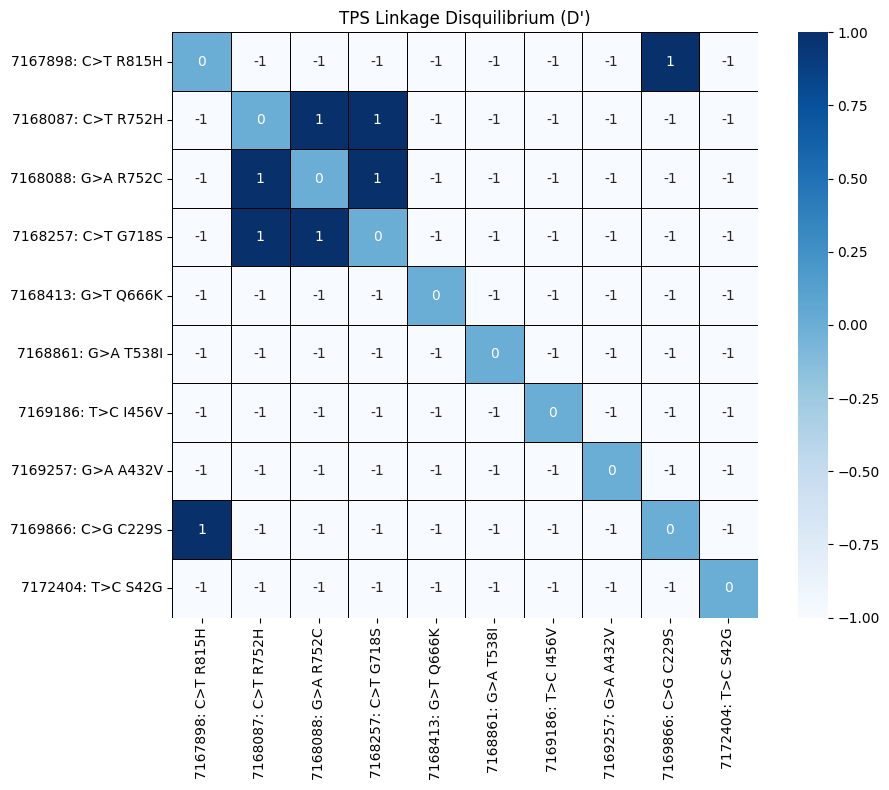

In [40]:
def plot_ld_with_gridspec(ld_df, title="TPS Linkage Disquilibrium (D')"):
    n = ld_df.shape[0]

    # -------------------------------------------
    # 1. Setup GridSpec for the plot
    # -------------------------------------------
    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(1, 1, figure=fig)

    ax = fig.add_subplot(gs[0, 0])

    # -------------------------------------------
    # 2. Draw the heatmap
    # -------------------------------------------
    sns.heatmap(
        ld_df,
        cmap="Blues",
        vmin=-1, vmax=1, center=0,
        annot=True,
        square=True,
        linewidths=0.5,        # visible gridlines!
        linecolor="black",     # gridline color
        xticklabels=True,
        yticklabels=True,
        ax=ax
    )

    # -------------------------------------------
    # 3. Axis and title formatting
    # -------------------------------------------
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.tick_params(axis='both', which='major')

    plt.tight_layout()
    plt.show()


# Example usage:
plot_ld_with_gridspec(ld_df)
